In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fake-news-classification/WELFake_Dataset.csv


In [3]:
# !pip install nltk

In [4]:
data=pd.read_csv("/kaggle/input/fake-news-classification/WELFake_Dataset.csv")

In [5]:
data.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [6]:
### dimension
data.shape

(72134, 4)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [8]:
## drop Unnamed column 
data.drop('Unnamed: 0',axis=1,inplace=True)

In [9]:
data.isnull().sum()

title    558
text      39
label      0
dtype: int64

In [10]:
## dropna 
data=data.dropna(axis=0)

In [11]:
data.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [12]:
## checking duplicate data
data.duplicated().sum()

8416

In [13]:
## drop duplicated data
data.drop_duplicates(inplace=True)

In [14]:
data.duplicated().sum()

0

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: ylabel='count'>

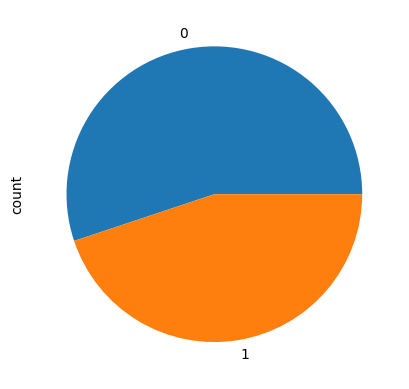

In [16]:
### pie chart of target 
data['label'].value_counts().plot(kind='pie')

In [17]:
from tqdm import tqdm
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
df=data.copy()

In [19]:
df['news']=df['title']+" "+df['text']

In [20]:
df.head()

,title,text,label,news
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1,About Time! Christian Group Sues Amazon and SP...


In [21]:
df.drop(['title','text'],axis=1,inplace=True)

In [22]:
df.head()

,label,news
0,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
2,1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,1,SATAN 2: Russia unvelis an image of its terrif...
5,1,About Time! Christian Group Sues Amazon and SP...


In [23]:
def preprocess_text(text_data):
    preprocessed_text = []

    for sentence in tqdm(text_data):
        sentence = re.sub(r'[^\w\s]', '', sentence)
        preprocessed_text.append(' '.join(token.lower()
                                  for token in str(sentence).split()
                                  if token not in stopwords.words('english')))

    return preprocessed_text

In [24]:
preprocessed_review = preprocess_text(df['news'].values)
df['news'] = preprocessed_review

100%|██████████| 63121/63121 [1:04:18<00:00, 16.36it/s]


In [25]:
dfcp=df.copy()
dfcp.to_csv("NewFAkedata.csv")

In [26]:
df.head()

,label,news
0,1,law enforcement on high alert following threat...
2,1,unbelievable obamas attorney general says most...
3,0,bobby jindal raised hindu uses story christian...
4,1,satan 2 russia unvelis image terrifying new su...
5,1,about time christian group sues amazon splc de...


## BAsics text statistics

In [27]:
from wordcloud import WordCloud
from collections import Counter

In [28]:
# Count number of words in each news text
data["word_count"] = df["news"].apply(lambda x: len(str(x).split()))
data["char_count"] = df["news"].apply(lambda x: len(str(x)))

# Summary statistics
print(data[["word_count", "char_count"]].describe())

         word_count     char_count
count  63121.000000   63121.000000
mean     341.166236    2451.025903
std      369.811750    2604.851822
min        2.000000      11.000000
25%      158.000000    1131.000000
50%      256.000000    1857.000000
75%      422.000000    3055.000000
max    20731.000000  137970.000000


### WOrd count distribution

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


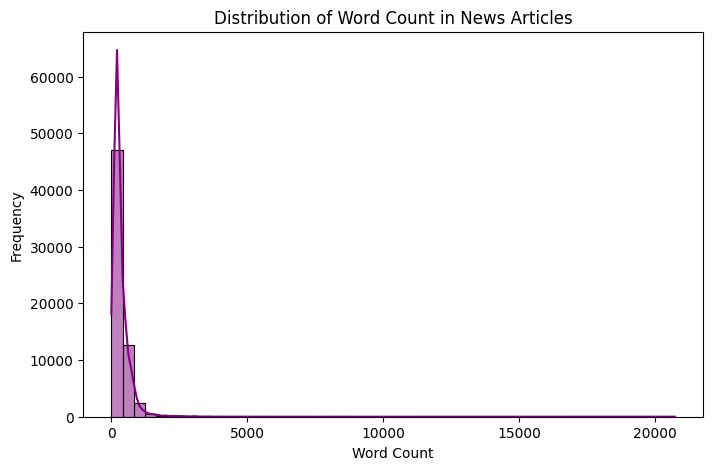

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(data["word_count"], bins=50, kde=True, color='purple')
plt.title("Distribution of Word Count in News Articles")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

### Most Common Words in Fake & Real News

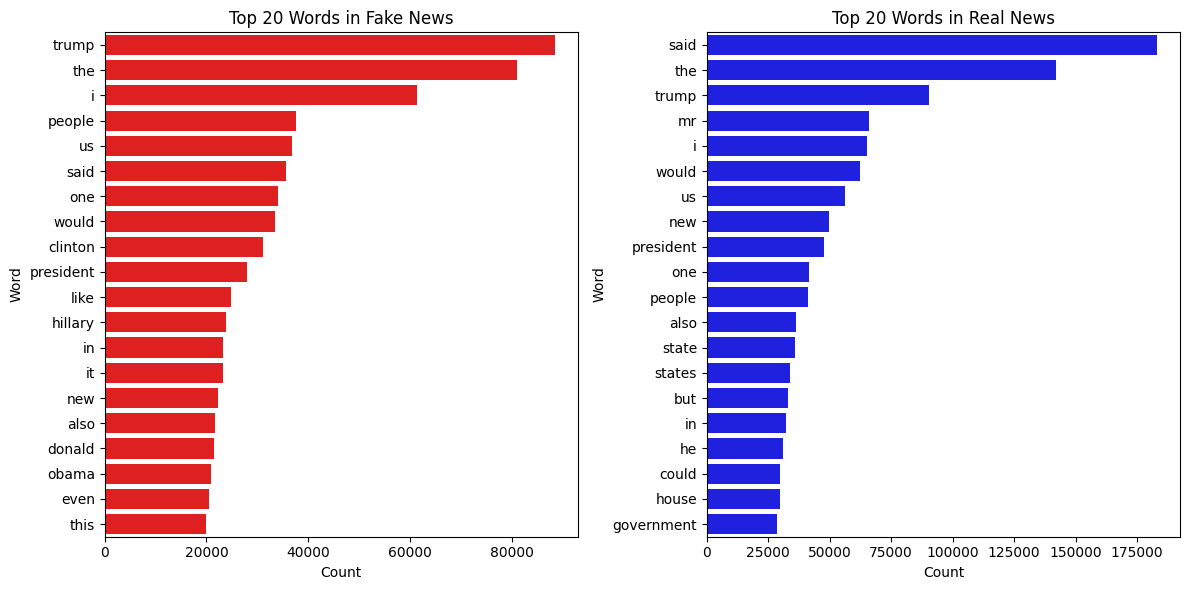

In [30]:
# Tokenize words
fake_words = " ".join(df[df["label"] == 1]["news"]).split()
real_words = " ".join(df[df["label"] == 0]["news"]).split()

# Count top 20 words in Fake News
fake_word_freq = Counter(fake_words).most_common(20)
real_word_freq = Counter(real_words).most_common(20)

fake_df = pd.DataFrame(fake_word_freq, columns=["Word", "Count"])
real_df = pd.DataFrame(real_word_freq, columns=["Word", "Count"])

fig, ax = plt.subplots(1, 2, figsize=(12,6))

sns.barplot(x="Count", y="Word", data=fake_df, ax=ax[0], color="red")
ax[0].set_title("Top 20 Words in Fake News")

sns.barplot(x="Count", y="Word", data=real_df, ax=ax[1], color="blue")
ax[1].set_title("Top 20 Words in Real News")

plt.tight_layout()
plt.show()


In [31]:
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [32]:
# Tokenization
max_words = 10000  # Vocabulary size
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df["news"])

In [33]:
# Convert words to sequences
sequences = tokenizer.texts_to_sequences(df["news"])

In [34]:
# Padding to ensure uniform input size
max_length = 200  # Max sequence length
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding="post", truncating="post")

# Check the padded sequences
print(padded_sequences[:2])

[[  71  672  135  324 4206  437 1263 2873 2693   43 3177  135    1    1
    43    1 1102  110  326  392  432  434   28  180    1    1    1 3656
   100    1 5250   39    8 2693   72 3196  280 1099  156  157  299  655
  7399 1355   39    8 2693 1177  582 1109  155    8    1    1 4870  100
     1  136 1099 3193  156 3533  462  100    1    1 1050 1099  156   26
     1    1    1  167 1125    1 1514  591 3100  309  258    1 2608  383
  5888 8445   39 5327    1  167 1099  258 6205    1 1099  156 5896 3404
  1514  965 1778    1  156    1  921  258    1 1109   39    1    1 3460
  4092 1099  156  844   20 1131  446  462  454    6   18 2296    1   17
   192  620  409 1263  699    1    1  511    1 6161  155  152    3  876
     1  485    1   18    7 3785    1    1    9    7 3079   17    3  875
   192 3079 5428 3011  146  572  924  155  876    1   90   39  356 2570
  4640  376  655 7763   72    1 2693  656 1589    8   16 1440   17 9906
     9   29  194    6  845    1 1972   96    1   55  485    1   

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional  ,Dropout, BatchNormalization
from tensorflow.keras.regularizers import  l2
from tensorflow.keras.callbacks import EarlyStopping

In [73]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=5,
    restore_best_weights=True
) 

In [74]:
# Model parameters
embedding_dim = 20  # Size of word embeddings

# # Define model architecture
# model = Sequential([
#     Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_length),
#     Bidirectional(LSTM(64, return_sequences=True)),  # BiLSTM for better context understanding
#     Bidirectional(LSTM(32)),  # Another LSTM layer
#     Dense(16, activation="relu"),
#     Dense(1, activation="sigmoid")  # Binary classification
# ])
model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_length),
    Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.01))),
    BatchNormalization(),  # Batch normalization after LSTM layer
    Dropout(0.5),
    Bidirectional(LSTM(32, kernel_regularizer=l2(0.01))),
    BatchNormalization(),  # Batch normalization after second LSTM layer
    Dropout(0.5),
    Dense(16, activation="relu", kernel_regularizer=l2(0.01)),
    BatchNormalization(),  # Batch normalization before dense layer
    Dense(1, activation="sigmoid")
])

# Compile model
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

# Print model summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_7 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_8 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ ?                           │     0 (unbuilt) │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
from sklearn.model_selection import train_test_split

In [38]:
# Encode labels
y = data["label"].values  # Assuming 'label' column contains 0 or 1

In [62]:
# Split data
X_t, X_val, y_t, y_val = train_test_split(padded_sequences, y, test_size=0.2, random_state=42,stratify=y)

In [63]:
X_train,X_test,y_train,y_test = train_test_split(X_t, y_t, test_size=0.2, random_state=42,stratify=y_t)

In [75]:
# Train the model[early_stopping]
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test),callbacks=[early_stopping])

Epoch 1/5
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.8935 - loss: 1.1520 - val_accuracy: 0.9505 - val_loss: 0.1785
Epoch 2/5
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9671 - loss: 0.1210 - val_accuracy: 0.9617 - val_loss: 0.1695
Epoch 3/5
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9802 - loss: 0.0835 - val_accuracy: 0.9598 - val_loss: 0.1461
Epoch 4/5
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9826 - loss: 0.0782 - val_accuracy: 0.9574 - val_loss: 0.1709
Epoch 5/5
1263/1263 ━━━━━━━━━━━━━━━━━━━━ 41s 32ms/step - accuracy: 0.9869 - loss: 0.0589 - val_accuracy: 0.9607 - val_loss: 0.1537


In [76]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

316/316 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9604 - loss: 0.1434
Test Accuracy: 95.98%


In [77]:
## with validation data 
lossVal, accuracyVal= model.evaluate(X_val , y_val)
print(f"Validation Accuracy: {accuracyVal * 100:.2f}%")

395/395 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9625 - loss: 0.1359
Validation Accuracy: 96.06%


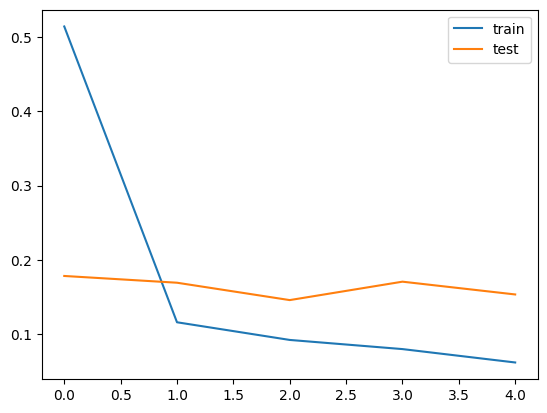

In [78]:
## plot all loss history
plt.plot(history.history['loss'],label='train') # Changed model.history.history to history.history
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

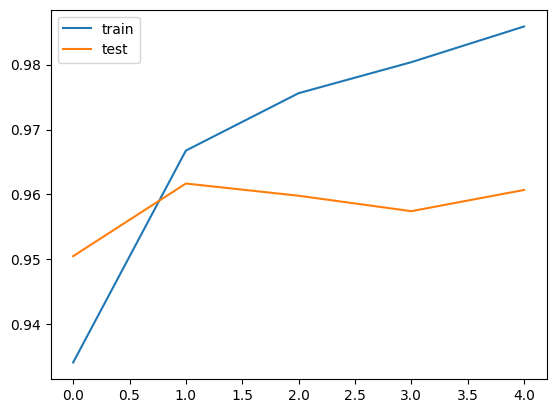

In [79]:
## plotting score
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='test')
plt.legend()
plt.show()

In [80]:
model.save('my_model.h5') ## saving model's parameters 